In [1]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt # Библиотека за визуелизација
import seaborn as sns
import numpy as np # Библиотека за нумерички анализи
import pandas as pd
from scipy import stats # Библиотека за статистички анализи
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler # Min max Scaler за нормализација на податоци во опсег [0,1]
from sklearn.linear_model import LinearRegression  # Вчитување на модели за линерна регресија
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # За евалуација на модели

In [3]:
data = pd.read_csv("student_scores.csv")

In [4]:
data.head(10)

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


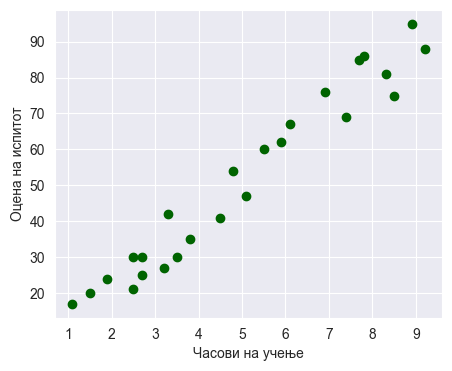

In [5]:
# Приказ на податоците со дијаграм на растурање
plt.figure(figsize=(5, 4))
plt.scatter(data["Hours"], data["Scores"], color = 'darkgreen')
plt.xlabel("Часови на учење")
plt.ylabel("Оцена на испитот")
plt.show()

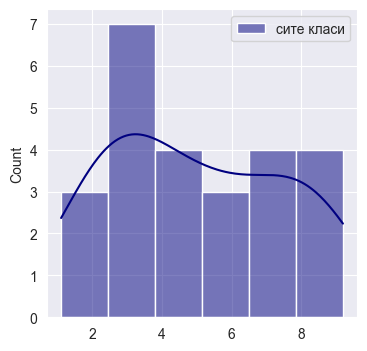

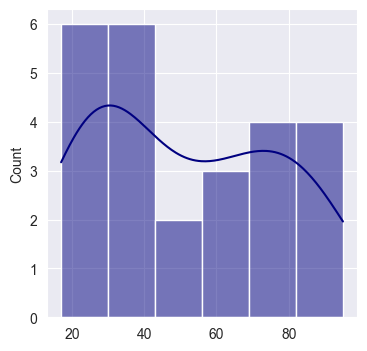

In [6]:
number_of_features = 1
number_of_targets = 1
X = data["Hours"].values.reshape(-1,1) #mora vaka
y = data["Scores"].values
N = len(y)

fig = plt.figure(figsize=(4, 4))
fig.subplots(nrows=1, ncols=1)

for feat_i in range(number_of_features):
    ax = plt.subplot(1,1, feat_i+1)
    sns.histplot(X[:,feat_i],color='navy',label="сите класи",kde=True,stat="count") # се прикажува хистограм на вредностите на соодветниот атрибут без разлика во која класа припаѓаат
    plt.legend()
plt.show()

fig = plt.figure(figsize=(4, 4))
sns.histplot(y, color = "navy", kde=True)
plt.show()

In [7]:
#se korelirani

In [8]:
reg = LinearRegression()
reg.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
new_data = pd.DataFrame([7, 8, 9]) #novi vlezni parametri (7h, 8h, 9h)
predictions = reg.predict(new_data)
print(predictions)

[70.91429714 80.69010053 90.46590392]


In [10]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [11]:
reg = LinearRegression().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

Коефициенти W:  [78.65538158]
Пресек W0:  13.475791706651854
Средна квадратна грешка: 23.61945761415175
Средна апсолутна грешка: 4.499999999999997
Корен на средна квадратна грешка: 4.8599853512281035
R-квадрат:  0.9487647340257012


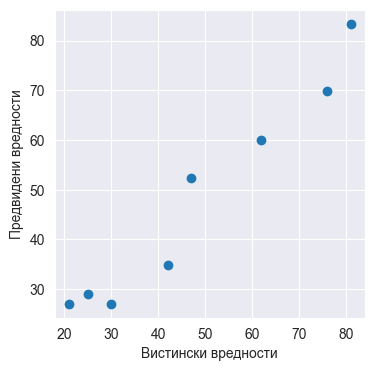

In [14]:
# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

#👉 Секоја точка на графикот е: (вистинска вредност,предвидена вредност)
#✅Ако моделот е совршен: сите точки ќе лежат на линија: y=x
#❌ Ако има грешка: точките ќе бидат расфрлани

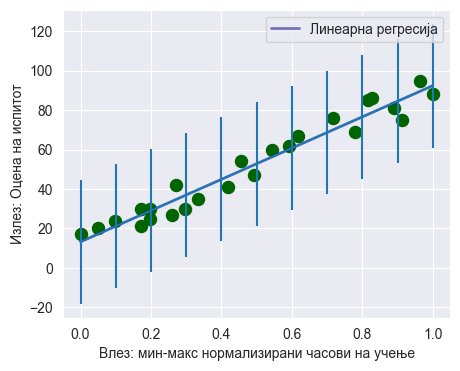

In [15]:
lr = LinearRegression() # иницијализација на моделот
lr.fit(X, y) # поставете го моделот на податоците
lrsigma = np.sum((y - lr.predict(X))**2) /(N-2) # пресметка на варијансата

line_X = np.arange(0, 1.1, 0.1)[:, np.newaxis] #vlezni vr sho gi koristime za da ja nacrtame linijata
line_y = lr.predict(line_X) #predict na tie od X
#gi davat tocjkite (line_X[i], line_y[i]) niz koi ke odi pravata


lw = 2 # параметар за визуелизација (linewidth)
plt.figure(figsize=(5, 4))
plt.scatter(X, y, color='darkgreen', marker='.', s = 300)
plt.plot(line_X, line_y, color='navy', linewidth=lw, label='Линеарна регресија', alpha=0.5)
plt.errorbar(line_X, line_y,yerr=lrsigma) # покажува неизвесност / грешка
#колку може да варира вистинската вредност

plt.legend(loc='best')
plt.xlabel("Влез: мин-макс нормализирани часови на учење")
plt.ylabel("Излез: Оцена на испитот")
plt.show()

In [16]:
import matplotlib.pyplot as plt #Библиотека за визуелизација
import seaborn as sns
import numpy as np #Библиотека за нумерички анализи
import pandas as pd
from scipy import stats #Библиотека за статистички анализи
from sklearn.model_selection import train_test_split
from sklearn import datasets #Библиотека за податочни множества за машинско учење
from sklearn.preprocessing import MinMaxScaler #Min max Scaler за нормализација на податоци во опсег [0,1]
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge #Вчитување на модели за линерна регресија
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #За евалуација на модели
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.datasets import fetch_california_housing

In [17]:
california_housing = datasets.fetch_california_housing()
df = datasets.fetch_california_housing(as_frame=True).frame

In [18]:
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [19]:
X = california_housing.data # Х матрицата одговара на влезните вектори, каде што секој ред одговара на податочна точка, а секоја колона одговара на карактеристика (атрибут)
y = california_housing.target # Векторот y одговара на излезните вредности, каде што i-тата вредност е класата на i-тиот вектор на атрибут (ред) во X
number_of_features=X.shape[1]
number_of_targets=1
feature_names = california_housing.feature_names
target_names = california_housing.target_names
print("Имиња на излезните класи: ", target_names)
N = X.shape[0]

print("Број на карактеристики (атрибути): ", X.shape[1]) #бројот на атрибути одговара на бројот на колони во X матрицата
print("Број на излезни класи: ", len(target_names)) # или number_of_targets
print("Број на инстанци: ", X.shape[0]) # или N

Имиња на излезните класи:  ['MedHouseVal']
Број на карактеристики (атрибути):  8
Број на излезни класи:  1
Број на инстанци:  20640


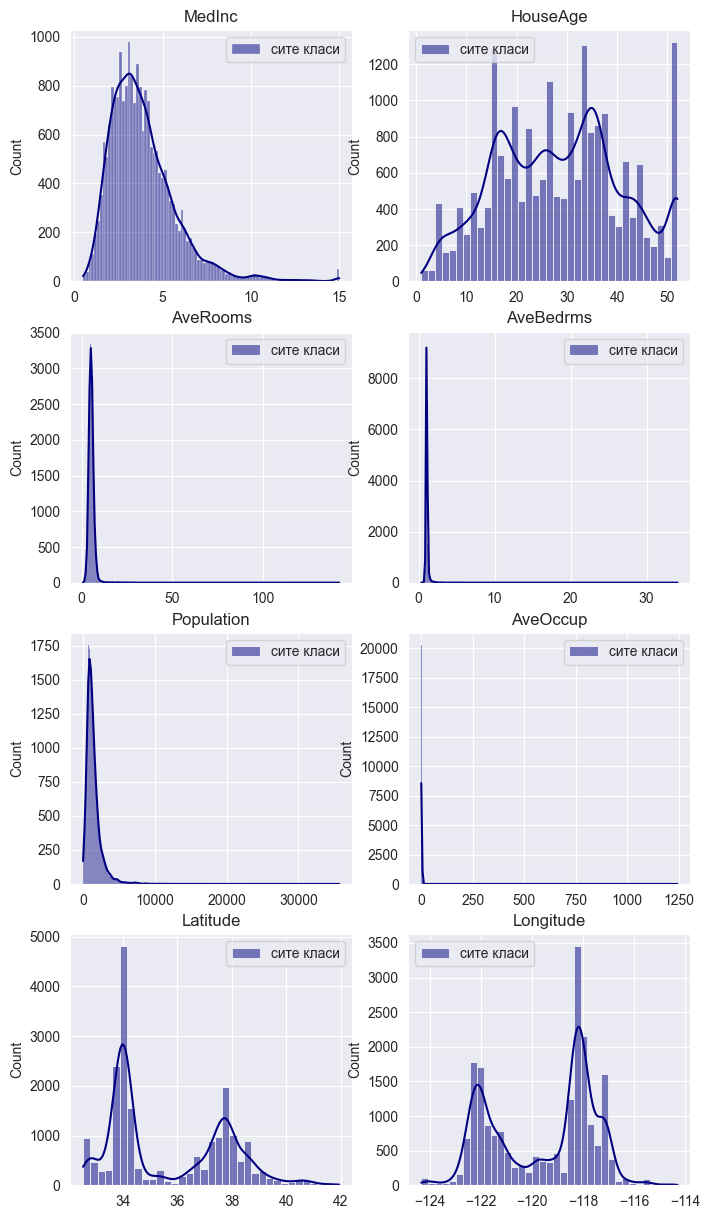

In [20]:
fig = plt.figure(figsize=(8, 15))
fig.subplots(nrows=4, ncols=2)
for feat_i in range(number_of_features): #хистограми за секој атрибут
    ax = plt.subplot(4,2, feat_i+1)
    plt.title(feature_names[feat_i])
    sns.histplot(X[:,feat_i],color='navy',label='сите класи',kde=True,stat="count") # се прикажува хистограм на вредностите на соодветниот атрибут без разлика во која класа припаѓаат
    plt.legend()
plt.show()

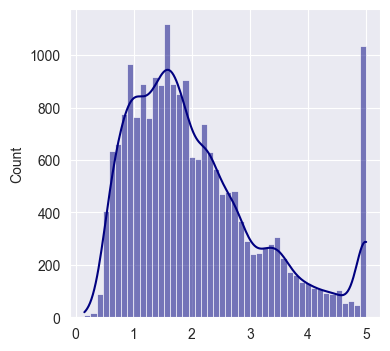

In [21]:
fig = plt.figure(figsize=(4, 4))
sns.histplot(y, color = "navy", kde=True)
plt.show()

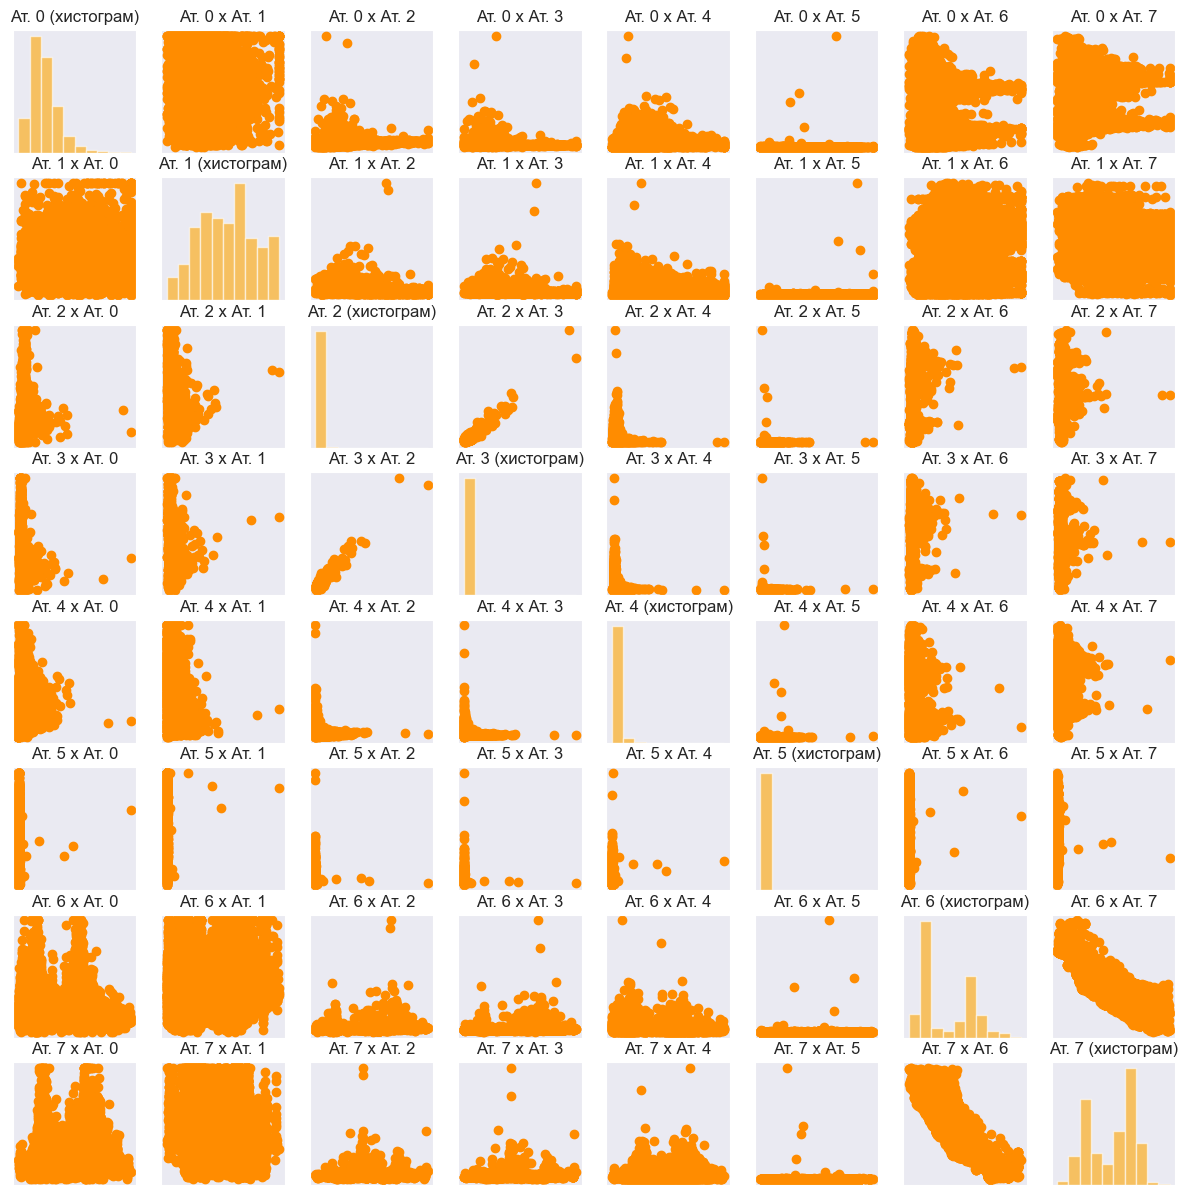

In [22]:
#sccatter sekoj so sekoj

fig = plt.figure(figsize=(15, 15))
fig.subplots(nrows=number_of_features, ncols=number_of_features)
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        ax = plt.subplot(number_of_features,number_of_features,number_of_features*feature_i + feature_j+1)
        if feature_i==feature_j:
          plt.hist(X[:, feature_i], alpha=.6, color="orange")
          plt.title("Ат. "+str(feature_i)+" (хистограм)")
        else:
          plt.scatter(X[:,feature_i], X[:,feature_j], color="darkorange")
          plt.title("Ат. "+str(feature_i)+" x Ат. "+str(feature_j)) # Атрибут i x Атрибут ј
          #plt.title(feature_names[feature_i] +" x "+feature_names[feature_j]) # Атрибут i x Атрибут ј
        plt.xticks(())
        plt.yticks(())
plt.show()

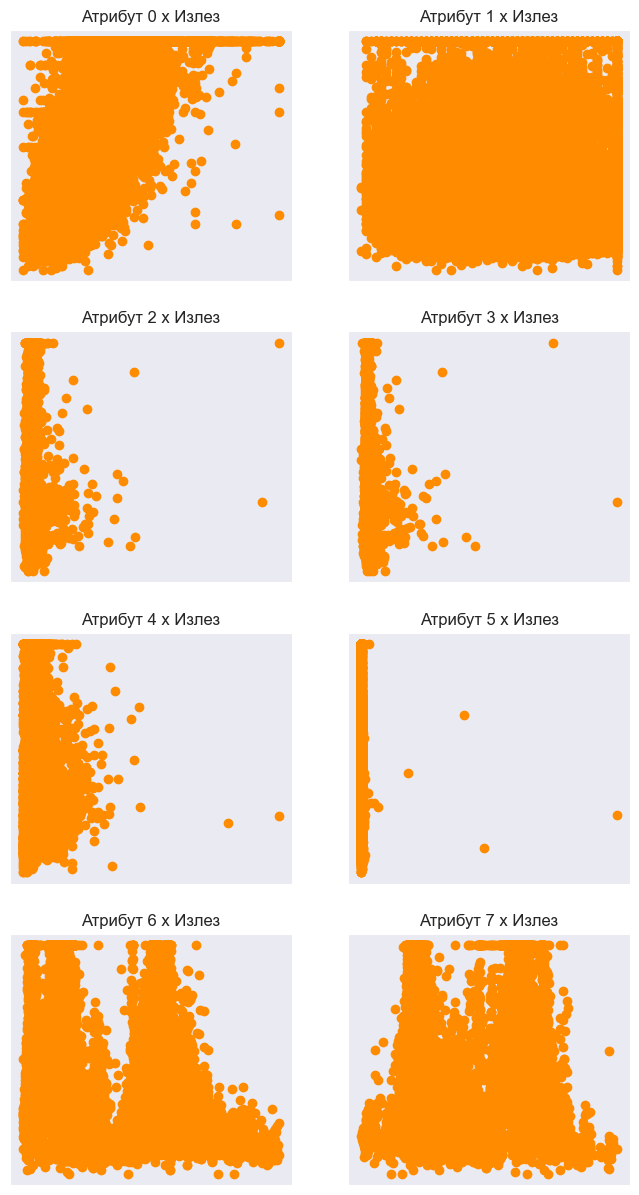

In [23]:
#vizulizacija na sekoj so izlezot

fig = plt.figure(figsize=(8, 15))
fig.subplots(nrows=(int)(number_of_features/2),ncols=2)
for feat_i in range(number_of_features):
    ax = plt.subplot(4,2, feat_i+1)
    plt.scatter( X[:,feat_i], y, color="darkorange")
    plt.xticks(())
    plt.yticks(())
    plt.title("Атрибут "+str(feat_i)+" x Излез")
plt.show()

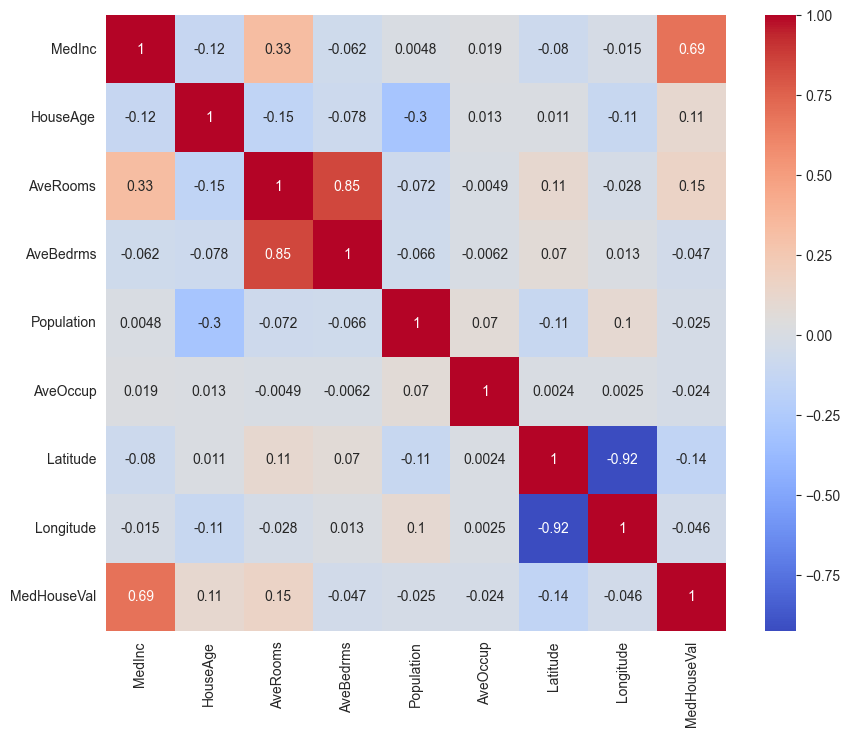

In [24]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

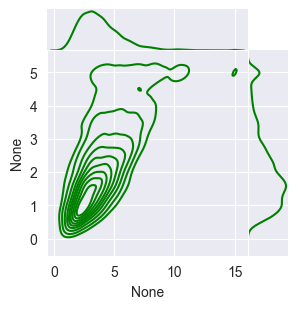

In [25]:
sns.jointplot(x=X[:,0], y=y, kind="kde", space=0, color="g", height = 3)
plt.show()
# откоментирајте го следниот код за приказ за секој атрибут
#for feature_i in range(number_of_features):
#    sns.jointplot(x=X[:,feature_i], y=y, kind="kde", space=0, color="g", height = 3)
#plt.show()

In [29]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
#Забележете дека бидејќи ова е малo податочно множество, не треба да го користиме стандардниот train_test_split
#за да ја процениме точноста на множеството податоци, туку треба да користиме вкрстена валидација.
#Меѓутоа, за едноставност, го правиме тоа во овој пример.

In [ ]:
#greshkite treba kon 0 a Rkvadrat kon 1
#R2 ги oбјаснува варијациите во податоците,
#Моделот се обидува да објасни:
#👉 „зошто некои вредности се 20, а некои 90?“

Коефициенти W:  [  6.46451636   0.49377527 -17.22309506  26.26475839  -0.02767764
  -4.1877334   -3.93843078  -4.35422728]
Пресек W0:  3.6401078266059628
Средна квадратна грешка: 0.5305677824766754
Средна апсолутна грешка: 0.5272474538305955
Корен на средна квадратна грешка: 0.7284008391515453
R-квадрат:  0.5957702326061662


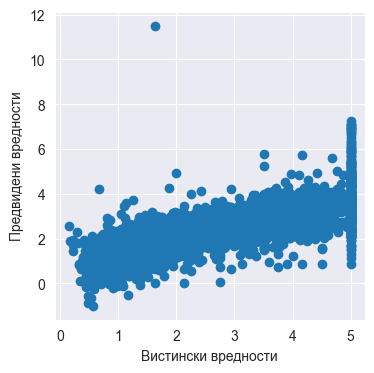

In [27]:
reg = LinearRegression().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Коефициенти W:  [ 5.58798988  0.50340364 -1.46588     6.11300155 -0.04889709 -2.2967199
 -4.15779262 -4.52363121]
Пресек W0:  3.9330023942258805
Средна квадратна грешка: 0.527137808285123
Средна апсолутна грешка: 0.5349154050059373
Корен на средна квадратна грешка: 0.7260425664416124
R-квадрат:  0.5983834664198477


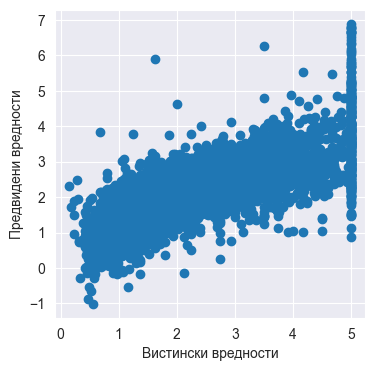

In [28]:
reg = Ridge(alpha=1).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Коефициенти W:  [ 0.26920081  0.          0.         -0.         -0.         -0.
 -0.         -0.        ]
Пресек W0:  2.006544689282036
Средна квадратна грешка: 1.2585434457041687
Средна апсолутна грешка: 0.8875338621644704
Корен на средна квадратна грешка: 1.1218482275709887
R-квадрат:  0.041139056847283806


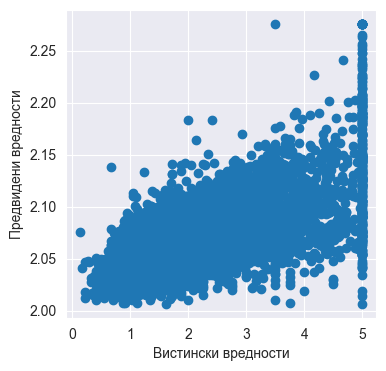

In [30]:
reg = Lasso(alpha = 0.1).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Коефициенти W:  [ 0.85560637  0.02878362  0.         -0.         -0.         -0.
 -0.04319036 -0.        ]
Пресек W0:  1.8686894248782142
Средна квадратна грешка: 1.1445063413799779
Средна апсолутна грешка: 0.8461779498819662
Корен на средна квадратна грешка: 1.069816031558687
R-квадрат:  0.12802181467335005


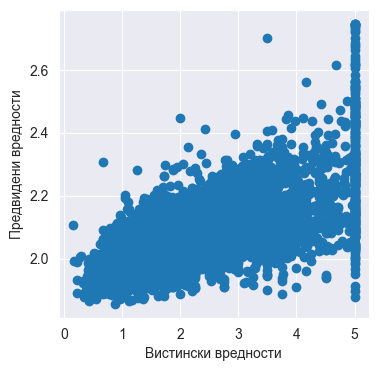

In [31]:
reg = ElasticNet(alpha = 0.1, l1_ratio = 0.3).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Коефициенти W:  [  6.44564121   0.49395311 -16.87983943  25.84060213  -0.0274159
  -4.16973249  -3.94508501  -4.36006089]
Пресек W0:  3.6477721050022054
Средна квадратна грешка: 0.5302212495792438
Средна апсолутна грешка: 0.5273120115983123
[0.72839825 0.72755105 0.72837464 ... 0.72853518 0.72879441 0.72833731]
6192
Корен на средна квадратна грешка: 0.7281629279077889
R-квадрат:  0.5960342496029565


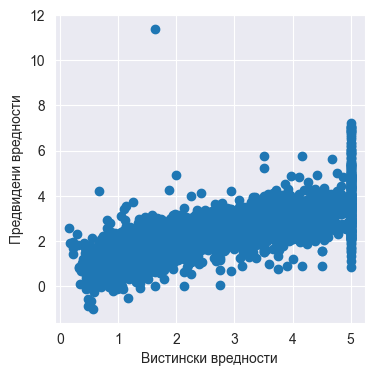

In [32]:
reg = BayesianRidge().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred, y_std = reg.predict(X_test, return_std = True) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print(y_std)
print(len(y_std))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

In [33]:
#kolku prvio feuture vlijaj na atributite

Xi=X[:,0].reshape(-1,1)
print("Xi=", Xi)
print("y=",y)

# поставете модел на линеарна регресија
lr = LinearRegression() # иницијализација на моделот
lr.fit(Xi, y) # поставете го моделот на податоците
lrsigma = np.sum((y - lr.predict(Xi))**2) /(N-2) # пресметка на варијансата на моделот

# поставете модел на риџ регресија
ridge = Ridge(alpha=1)
ridge.fit(Xi, y)
ridgesigma = np.sum((y - ridge.predict(Xi))**2) /(N-2)

# поставете модел на ласо регресија
lasso = Lasso(alpha=0.1)
lasso.fit(Xi, y)
lassosigma = np.sum((y - lasso.predict(Xi))**2) /(N-2)

# поставете модел на еластична мрежа
elastic = ElasticNet(alpha=0.1, l1_ratio = 0.4)
elastic.fit(Xi, y)
elasticsigma = np.sum((y - elastic.predict(Xi))**2) /(N-2)

# поставете модел на баесова риџ регресија
Bayes = BayesianRidge()
Bayes.fit(Xi, y)

print("Коефициенти на моделите")
print("Линеарна регресија: ",lr.coef_)
print("Риџ регресија: ", ridge.coef_)
print("Ласо регресија: ", lasso.coef_)
print("Регресија на еластична мрежа:", elastic.coef_)
print("Баесова риџ регресија: ", Bayes.coef_)

Xi= [[0.53966842]
 [0.53802706]
 [0.46602805]
 ...
 [0.08276438]
 [0.09429525]
 [0.13025338]]
y= [4.526 3.585 3.521 ... 0.923 0.847 0.894]
Коефициенти на моделите
Линеарна регресија:  [6.06019172]
Риџ регресија:  [6.04313499]
Ласо регресија:  [0.23455592]
Регресија на еластична мрежа: [0.82972656]
Баесова риџ регресија:  [6.05986516]


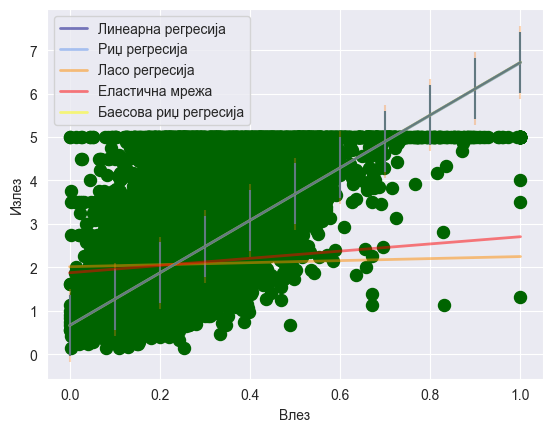

In [34]:
#Gi crta site regresioni modeli

# пресметка на линијата на секој модел во опсег [0, X.max()]
line_X = np.arange(0, 1.1, 0.1)[:, np.newaxis]
line_y = lr.predict(line_X)
line_y_ridge = ridge.predict(line_X)
line_y_lasso = lasso.predict(line_X)
line_y_elastic = elastic.predict(line_X)
line_y_bayes, Bayessigma = Bayes.predict(line_X, return_std = True) # во баесовиот модел може да се пресмета варијансата за секоја предикција

lw = 2 # параметар за визуелизација (linewidth)
plt.figure() # ги цртаме податочните точки и ги цртаме линиите што ги претставуваат различните модели, ги цртаме и лентите за грешки на моделите за линеарна и баесова риџ регресија
plt.scatter(Xi, y, color='darkgreen', marker='.', s = 300)
plt.plot(line_X, line_y, color='navy', linewidth=lw, label='Линеарна регресија', alpha=0.5)
plt.errorbar(line_X, line_y,yerr=lrsigma)
plt.plot(line_X, line_y_ridge, color='cornflowerblue', linewidth=lw, label='Риџ регресија', alpha=0.5)
plt.plot(line_X, line_y_lasso, color='darkorange', linewidth=lw, label='Ласо регресија', alpha=0.5)
plt.plot(line_X, line_y_elastic, color="red", linewidth=lw, label='Eластичнa мрежa', alpha=0.5)
plt.plot(line_X, line_y_bayes, color="yellow", linewidth=lw, label='Баесова риџ регресија', alpha=0.5)
plt.errorbar(line_X, line_y_bayes, yerr=Bayessigma, alpha = 0.3)

plt.legend(loc='best')
plt.xlabel("Влез")
plt.ylabel("Излез")
plt.show()

Обликот на X:  (20640, 1)
Обликот на трансформираната матрица Xt (20640, 2)
(20640, 2)
(20640,)
Коефициенти на моделите
Линеарна регресија:  [ 7.56345752 -2.20856672]
Риџ регресија:  [ 7.35927934 -1.93910953]
Ласо регресија:  [0.23455592 0.        ]
Еластична мрежа: [0.78851984 0.27215502]
Баесова риџ регресија:  [ 7.55863251 -2.20218046]
[[0.   0.  ]
 [0.1  0.01]
 [0.2  0.04]
 [0.3  0.09]
 [0.4  0.16]
 [0.5  0.25]
 [0.6  0.36]
 [0.7  0.49]
 [0.8  0.64]
 [0.9  0.81]
 [1.   1.  ]]


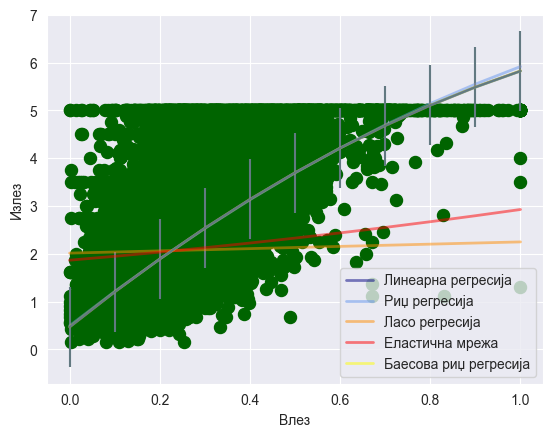

In [35]:
#Vo polinomna gi pretvora

p = np.array([1, 2]) # за едноставен еднодимензионален случај, можеме да направиме проширување на основната функција вака
Xt = Xi ** p # забележете дека Xt сега има две карактеристики (едната претставува X, а другата претставува X^2)
print("Обликот на X: ", Xi.shape)
print("Обликот на трансформираната матрица Xt", Xt.shape)

print(Xt.shape)
print(y.shape)

# поставете модел на линеарна регресија
lr = LinearRegression() # иницијализација на моделот
lr.fit(Xt, y) # поставете го моделот на податоците
lrsigma = np.sqrt(np.sum((y - lr.predict(Xt))**2) /(N-2)) # пресметка на варијанската на моделот

# поставете модел на риџ регресија
ridge = Ridge(alpha=1)
ridge.fit(Xt, y)
ridgesigma = np.sum((y - ridge.predict(Xt))**2) /(N-2)

# поставете модел на ласо регресија
lasso = Lasso(alpha=0.1)
lasso.fit(Xt, y)
lassosigma = np.sum((y - lasso.predict(Xt))**2) /(N-2)

# поставете модел на регресија на еластична мрежа
elastic = ElasticNet(alpha=0.1, l1_ratio = 0.4)
elastic.fit(Xt, y)
elasticsigma = np.sum((y - elastic.predict(Xt))**2) /(N-2)

# поставете модел на баесовa риџ регресија
Bayes = BayesianRidge()
Bayes.fit(Xt, y)

print("Коефициенти на моделите")
print("Линеарна регресија: ",lr.coef_)
print("Риџ регресија: ", ridge.coef_)
print("Ласо регресија: ", lasso.coef_)
print("Еластична мрежа:", elastic.coef_)
print("Баесова риџ регресија: ", Bayes.coef_)

# пресметка на линијата на секој модел во опсег [0, X1.max()]
line_X0 = np.arange(0, 1.1, 0.1)[:, np.newaxis]
line_X1 = line_X0*line_X0
line_X = np.concatenate((line_X0,line_X1),1)
print(line_X)
line_y = lr.predict(line_X)
line_y_ridge = ridge.predict(line_X)
line_y_lasso = lasso.predict(line_X)
line_y_elastic = elastic.predict(line_X)
line_y_bayes, Bayessigma = Bayes.predict(line_X, return_std = True) # во баесовиот модел може да се пресмета варијансата за секоја предикција

M=line_X1.size
lrsigma_array=np.ones(M)*lrsigma

lw = 2 # параметар за визуелизација (linewidth)
plt.figure() # ги цртаме податочните точки и ги цртаме линиите што ги претставуваат различните модели, ги цртаме и лентите за грешки на моделите за линеарна и баесова риџ регресија
plt.scatter(Xi, y, color='darkgreen', marker='.', s = 300)
plt.plot(line_X0, line_y, color='navy', linewidth=lw, label='Линеарна регресија', alpha=0.5)
plt.errorbar(line_X0, line_y.flatten(), yerr=lrsigma_array)
plt.plot(line_X0, line_y_ridge, color='cornflowerblue', linewidth=lw, label='Риџ регресија', alpha=0.5)
plt.plot(line_X0, line_y_lasso, color='darkorange', linewidth=lw, label='Ласо регресија', alpha=0.5)
plt.plot(line_X0, line_y_elastic, color="red", linewidth=lw, label='Еластична мрежа', alpha=0.5)
plt.plot(line_X0, line_y_bayes, color="yellow", linewidth=lw, label='Баесова риџ регресија', alpha=0.5)
plt.errorbar(line_X0, line_y_bayes, yerr=Bayessigma, alpha = 0.3)

plt.legend(loc='best')
plt.xlabel("Влез")
plt.ylabel("Излез")
plt.show()

In [36]:
#selekcija na atrbuti izbira samo k najdobri

selector = SelectKBest(f_regression, k = 5)
X_train_new = selector.fit_transform(X_train, y_train)
X_test_new = selector.transform(X_test)
print(selector.get_support().astype(int))
print(X_train_new.shape)

[1 1 1 0 0 0 1 1]
(14448, 5)


Средна квадратна грешка (ново): 0.5317358993623593
Средна апсолутна грешка (ново): 0.5391200307613817
Корен на средна квадратна грешка (ново): 0.729202234885741
R-квадрат (ново):  0.5948802659843999


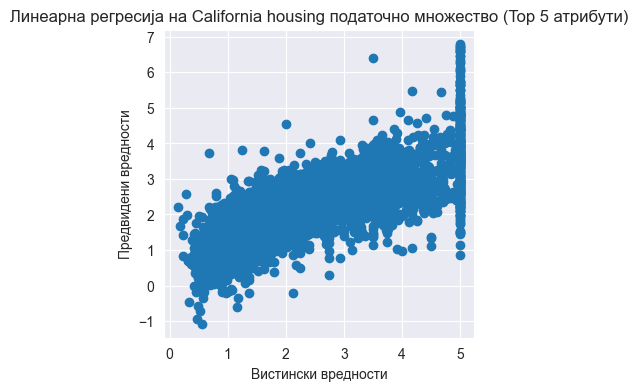

In [37]:
reg_new = LinearRegression()
reg_new.fit(X_train_new, y_train)
y_pred_new = reg_new.predict(X_test_new)
print("Средна квадратна грешка (ново):", mean_squared_error(y_test, y_pred_new))
print("Средна апсолутна грешка (ново):", mean_absolute_error(y_test, y_pred_new))
print("Корен на средна квадратна грешка (ново):", np.sqrt(mean_squared_error(y_test, y_pred_new)))
print("R-квадрат (ново): ", r2_score(y_test,y_pred_new)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred_new)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.title("Линеарна регресија на California housing податочно множество (Top 5 атрибути)")
plt.show()

In [38]:
#NOVO POD MNOZH ORING

In [39]:
import matplotlib.pyplot as plt #Библиотека за визуелизација
import seaborn as sns
import numpy as np #Библиотека за нумерички анализи
import pandas as pd
from scipy import stats #Библиотека за статистички анализи
from sklearn.model_selection import train_test_split
from sklearn import datasets #Библиотека за податочни множества за машинско учење
from sklearn.preprocessing import MinMaxScaler #Min max Scaler за нормализација на податоци во опсег [0,1]
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge #Вчитување на модели за линерна регресија
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #За евалуација на модели

In [40]:
df_data = pd.read_csv("Oring.csv") # Вчитување на податочното множество
column_names = np.loadtxt(open("Oring.csv", "rb"), delimiter=",", max_rows=1, dtype = str)
data = np.loadtxt(open("Oring.csv", "rb"), delimiter=",", skiprows=1, dtype = str)
data = data.astype(float)

In [41]:
df_data.head(5)

,Number experiencing thermal distress,Launch temperature (degrees F),Leak-check pressure (psi),Temporal order of flight
0,0,66,50,1
1,1,70,50,2
2,0,69,50,3
3,0,68,50,4
4,0,67,50,5


In [42]:
X = data[:,1:].astype(float) # другите колони ги претставуваат влезните податоци
y = data[:,0].astype(float)  # првата колона ја претставува излезната променлива
N = X.shape[0]
number_of_features = X.shape[1]
feature_names = column_names[1:]

print(X.shape)
print(y.shape)
print("Карактеристики (Атрибути): ", feature_names)
print("Број на карактеристики (атрибути):", X.shape[1]) # или number_of_features
print("Број на излезни класи: ", len(np.unique(y)))
print("Број на инстанци: ", X.shape[0]) # или N

(23, 3)
(23,)
Карактеристики (Атрибути):  ['Launch temperature (degrees F)' 'Leak-check pressure (psi)'
 'Temporal order of flight']
Број на карактеристики (атрибути): 3
Број на излезни класи:  3
Број на инстанци:  23


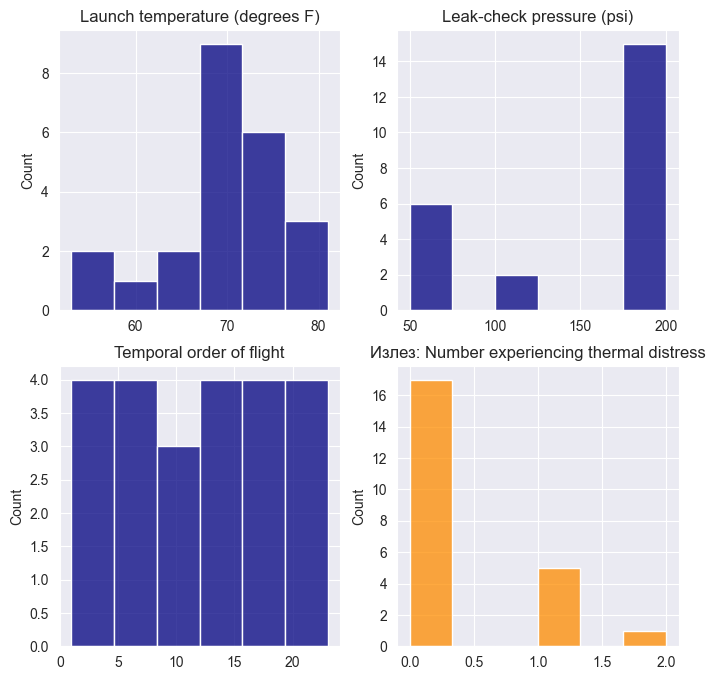

In [43]:
fig = plt.figure(figsize=(8, 8))
fig.subplots(number_of_features//2+1, ncols=2)
for feat_i in range(number_of_features): # хистограми за секој атрибут
    ax = plt.subplot(number_of_features//2+1,2, feat_i+1)
    plt.title(feature_names[feat_i])
    sns.histplot(X[:,feat_i], color = "navy")
ax = plt.subplot(number_of_features//2+1,2, feat_i+2)
plt.title("Излез: " + column_names[0])
sns.histplot(y, color = "darkorange") # хистограм за излезната променлива
plt.show()

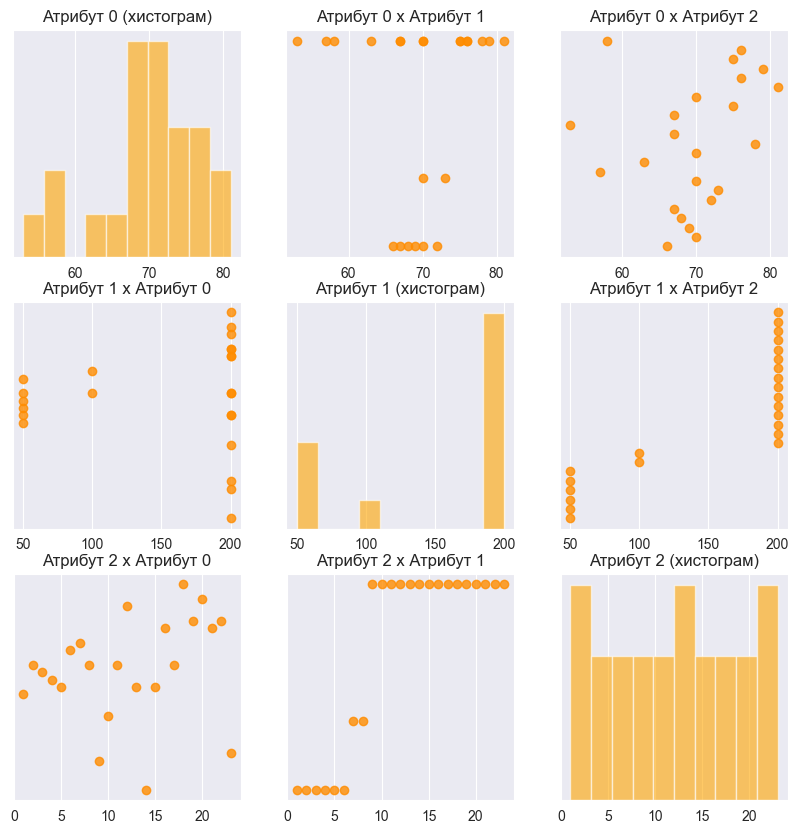

In [44]:
fig = plt.figure(figsize=(10, 10))
fig.subplots(nrows=number_of_features, ncols=number_of_features)
for feat_i in range(number_of_features): # за сите парови атрибути (3x3 во овој случај)
    for feat_j in range(number_of_features):
        ax = plt.subplot(number_of_features,number_of_features,number_of_features*feat_i + feat_j+1)
        if feat_i==feat_j:
          plt.hist(X[:, feat_i], alpha=.6, color="orange")
          plt.title("Атрибут "+str(feat_i)+" (хистограм)")
        else:
          plt.scatter(X[:,feat_i], X[:,feat_j],  alpha=.8, color="darkorange")
          plt.title("Атрибут "+str(feat_i)+" x Атрибут "+str(feat_j)) # Атрибут i x Атрибут ј
        plt.yticks(())
plt.show()

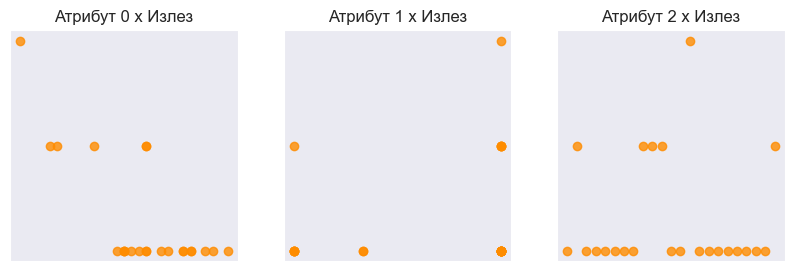

In [45]:
fig = plt.figure(figsize=(10, 3))
fig.subplots(ncols=number_of_features)
for feat_i in range(number_of_features):
    ax = plt.subplot(1 ,number_of_features, feat_i+1)
    plt.scatter( X[:,feat_i], y,  alpha=.8, color="darkorange")
    plt.xticks(())
    plt.yticks(())
    plt.title("Атрибут "+str(feat_i)+" x Излез")
plt.show()

In [46]:
# for feat_i in range(number_of_features):
#     sns.jointplot(x=X[:,feat_i], y=y, kind="kde", space=0, color="g", height = 3)
# plt.show()

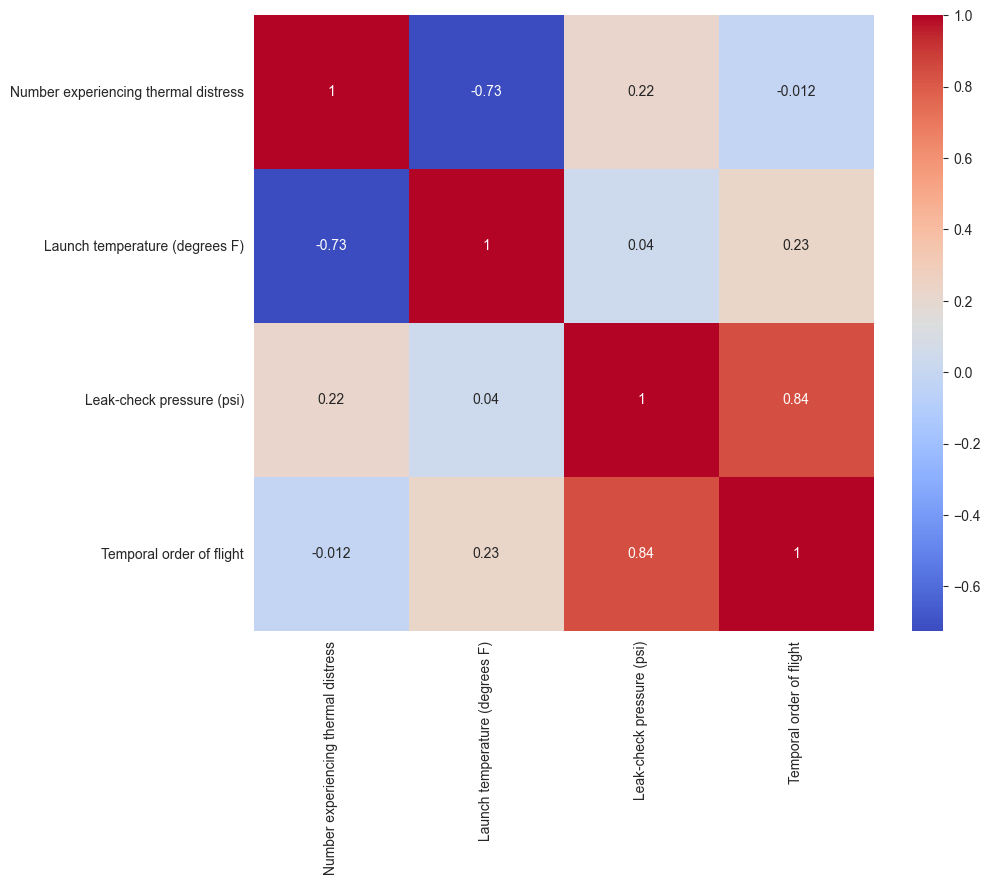

In [47]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [48]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
#Забележете дека бидејќи ова е малo податочно множество, не треба да го користиме стандардниот train_test_split
#за да ја процениме точноста на множеството податоци, туку треба да користиме вкрстена валидација.
#Меѓутоа, за едноставност, го правиме тоа во овој пример.

Коефициенти W:  [-1.82727115  0.88519349 -0.68056698]
Пресек W0:  1.1426492876719485
Средна квадратна грешка: 0.29076502173498003
Средна апсолутна грешка: 0.44350679818131933
Корен на средна квадратна грешка: 0.539226317732156
R-квадрат:  -0.18729050541783532


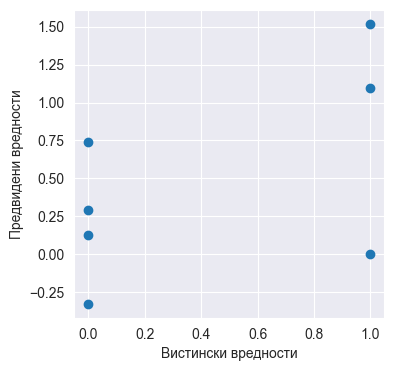

In [49]:
reg = LinearRegression().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

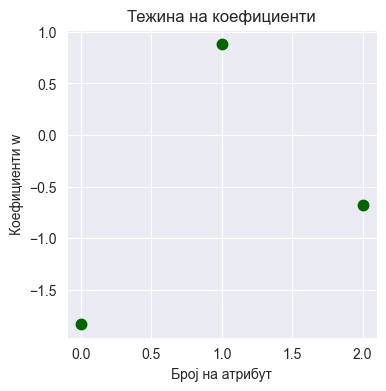

In [50]:
plt.figure(figsize=(4, 4))
plt.plot(np.arange(len(reg.coef_)), reg.coef_, ".",  markersize=15, color = "darkgreen")
plt.xlabel("Број на атрибут")
plt.ylabel("Коефициенти w")
plt.title("Тежина на коефициенти")
plt.show()

In [52]:
column_names = np.loadtxt(open("Oring.csv", "rb"), delimiter=",", max_rows=1, dtype = str)
data = np.loadtxt(open("Oring.csv", "rb"), delimiter=",", skiprows=1, dtype = str)
data = data.astype(float)
X = data[:,[1]].astype(float)  # атрибут 0
y = data[:,0].astype(float)
number_of_features = X.shape[1]
feature_names = column_names[1]
N = X.shape[0]

# поставете модел на линеарна регресија
lr = LinearRegression() # иницијализација на моделот
lr.fit(X, y) # поставете го моделот на податоците
lrsigma = np.sum((y - lr.predict(X))**2) /(N-2) # пресметка на варијансата на моделот

# поставете модел на риџ регресија
ridge = Ridge(alpha=1)
ridge.fit(X, y)
ridgesigma = np.sum((y - ridge.predict(X))**2) /(N-2)

# поставете модел на ласо регресија
lasso = Lasso(alpha=0.1)
lasso.fit(X, y)
lassosigma = np.sum((y - lasso.predict(X))**2) /(N-2)

# поставете модел на регресија на еластична мрежа
elastic = ElasticNet(alpha=0.1, l1_ratio = 0.4)
elastic.fit(X, y)
elasticsigma = np.sum((y - elastic.predict(X))**2) /(N-2)

# поставете модел на баесова риџ регресија
Bayes = BayesianRidge()
Bayes.fit(X, y)

print("Коефициенти на моделите")
print("Линеарна регресија: ",lr.coef_)
print("Риџ регресија: ", ridge.coef_)
print("Ласо регресија: ", lasso.coef_)
print("Еластична мрежа:", elastic.coef_)
print("Баесова риџ регресија: ", Bayes.coef_)

Коефициенти на моделите
Линеарна регресија:  [-0.05746032]
Риџ регресија:  [-0.05740792]
Ласо регресија:  [-0.05536111]
Еластична мрежа: [-0.05654941]
Баесова риџ регресија:  [-0.05511404]


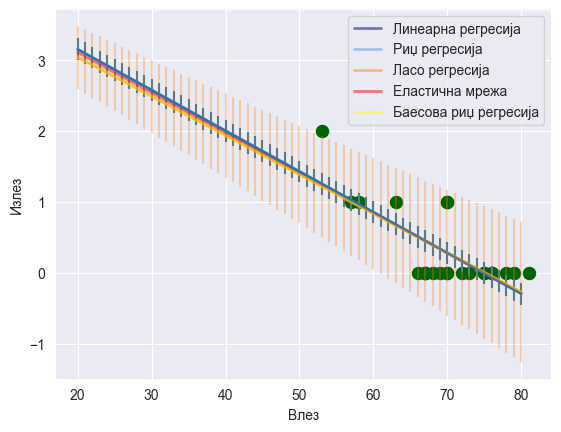

In [53]:
# пресметка на линијата на секој модел во опсег [20, X.max()]
line_X = np.arange(20, X.max())[:, np.newaxis]
line_y = lr.predict(line_X)
line_y_ridge = ridge.predict(line_X)
line_y_lasso = lasso.predict(line_X)
line_y_elastic = elastic.predict(line_X)
line_y_bayes, Bayessigma = Bayes.predict(line_X, return_std = True) # во баесовиот модел може да се пресмета варијансата за секоја предикција

lw = 2 # параметар за визуелизација (linewidth)
plt.figure() # ги цртаме податочните точки и ги цртаме линиите што ги претставуваат различните модели, ги цртаме и лентите за грешки на моделите за линеарна и баесова Ridge регресија
plt.scatter(X, y, color='darkgreen', marker='.', s = 300)
plt.plot(line_X, line_y, color='navy', linewidth=lw, label='Линеарна регресија', alpha=0.5)
plt.errorbar(line_X, line_y,yerr=lrsigma)
plt.plot(line_X, line_y_ridge, color='cornflowerblue', linewidth=lw, label='Риџ регресија', alpha=0.5)
plt.plot(line_X, line_y_lasso, color='darkorange', linewidth=lw, label='Ласо регресија', alpha=0.5)
plt.plot(line_X, line_y_elastic, color="red", linewidth=lw, label='Еластична мрежа', alpha=0.5)
plt.plot(line_X, line_y_bayes, color="yellow", linewidth=lw, label='Баесова риџ регресија', alpha=0.5)
plt.errorbar(line_X, line_y_bayes, yerr=Bayessigma, alpha = 0.3)

plt.legend(loc='best')
plt.xlabel("Влез")
plt.ylabel("Излез")
plt.show()

Обликот на X:  (23, 1)
Обликот на трансформираната матрица Xt (23, 2)
Коефициенти на моделите
Линеарна регресија:  [-0.51530904  0.00339352]
Риџ регресија:  [-0.42327102  0.00271421]
Ласо регресија:  [-0.01944666 -0.00026621]
Еластична мрежа: [-0.23790786  0.00134604]
Баесова риџ регресија:  [-0.41063466  0.00262095]


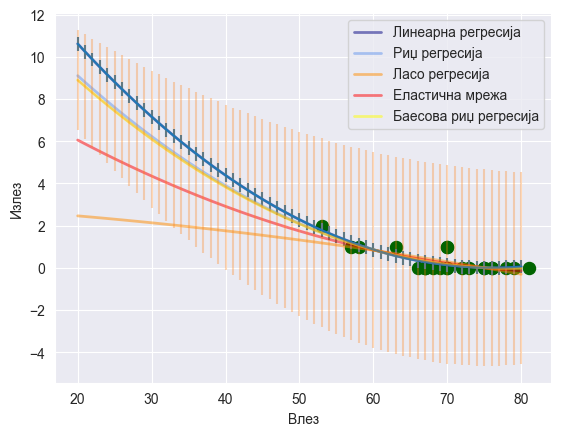

In [54]:
p = np.array([1, 2]) # за едноставен еднодимензионален случај, можеме да направиме проширување на основната функција вака
Xt = X ** p # забележете дека Xt сега има две карактеристики (едната претставува X, а другата претставува X^2)
print("Обликот на X: ", X.shape)
print("Обликот на трансформираната матрица Xt", Xt.shape)

# поставете модел на линеарна регресија
lr = LinearRegression() # иницијализација на моделот
lr.fit(Xt, y) # поставете го моделот на податоците
lrsigma = np.sqrt(np.sum((y - lr.predict(Xt))**2) /(N-2)) # пресметка на варијанската на моделот

# поставете модел на риџ регресија
ridge = Ridge(alpha=1)
ridge.fit(Xt, y)
ridgesigma = np.sum((y - ridge.predict(Xt))**2) /(N-2)

# поставете модел на ласо регресија
lasso = Lasso(alpha=0.1)
lasso.fit(Xt, y)
lassosigma = np.sum((y - lasso.predict(Xt))**2) /(N-2)

# поставете модел на регресија на еластична мрежа
elastic = ElasticNet(alpha=0.1, l1_ratio = 0.4)
elastic.fit(Xt, y)
elasticsigma = np.sum((y - elastic.predict(Xt))**2) /(N-2)

# поставете модел на баесовa риџ регресија
Bayes = BayesianRidge()
Bayes.fit(Xt, y)

print("Коефициенти на моделите")
print("Линеарна регресија: ",lr.coef_)
print("Риџ регресија: ", ridge.coef_)
print("Ласо регресија: ", lasso.coef_)
print("Еластична мрежа:", elastic.coef_)
print("Баесова риџ регресија: ", Bayes.coef_)

# пресметка на линијата на секој модел во опсег [0, X1.max()]
line_X = np.arange(20, X.max())[:, np.newaxis]
line_y = lr.predict(line_X ** p)
line_y_ridge = ridge.predict(line_X ** p)
line_y_lasso = lasso.predict(line_X ** p)
line_y_elastic = elastic.predict(line_X ** p)
line_y_bayes, Bayessigma = Bayes.predict(line_X**p, return_std = True) # во баесовиот модел може да се пресмета варијансата за секоја предикција

lw = 2 # параметар за визуелизација (linewidth)
plt.figure() # ги цртаме податочните точки и ги цртаме линиите што ги претставуваат различните модели, ги цртаме и лентите за грешки на моделите за линеарна и баесова риџ регресија
plt.scatter(X, y, color='darkgreen', marker='.', s = 300)
plt.plot(line_X, line_y, color='navy', linewidth=lw, label='Линеарна регресија', alpha=0.5)
plt.errorbar(line_X, line_y.flatten(), yerr=lrsigma)
plt.plot(line_X, line_y_ridge, color='cornflowerblue', linewidth=lw, label='Риџ регресија', alpha=0.5)
plt.plot(line_X, line_y_lasso, color='darkorange', linewidth=lw, label='Ласо регресија', alpha=0.5)
plt.plot(line_X, line_y_elastic, color="red", linewidth=lw, label='Еластична мрежа', alpha=0.5)
plt.plot(line_X, line_y_bayes, color="yellow", linewidth=lw, label='Баесова риџ регресија', alpha=0.5)
plt.errorbar(line_X, line_y_bayes, yerr=Bayessigma, alpha = 0.3)

plt.legend(loc='best')
plt.xlabel("Влез")
plt.ylabel("Излез")
plt.show()

Обликот на X:  (23, 1)
Обликот на трансформираната матрица Xt (23, 3)
Коефициенти на моделите
Линеарна регресија:  [-2.84006900e+00  3.82434471e-02 -1.72493282e-04]
Риџ регресија:  [-5.78323556e-02 -3.36874640e-03  3.30113777e-05]
Ласо регресија:  [-0.00000000e+00 -4.10019138e-03  3.59863933e-05]
Еластична мрежа: [-8.03388607e-03 -3.59892131e-03  3.16918407e-05]
Баесова риџ регресија:  [-5.85972629e-05 -3.62291151e-03  3.13555066e-05]


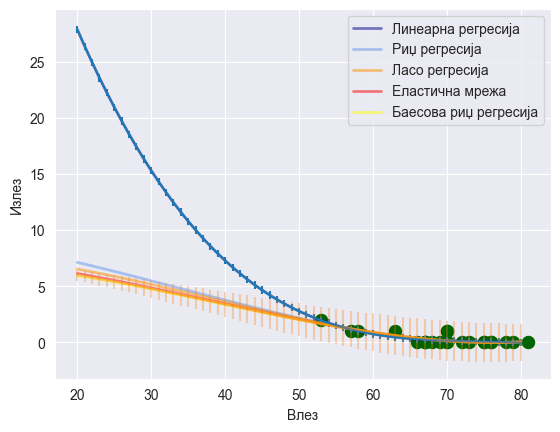

In [55]:
# kuben model
from sklearn import linear_model
p = np.array([1, 2, 3])
Xt = X ** p # забележете дека Xt сега има 3 атрибути (еден за X, еден за X^2 и еден за X^3)
print("Обликот на X: ", X.shape)
print("Обликот на трансформираната матрица Xt", Xt.shape)

# поставете модел на линеарна регресија
lr = LinearRegression() # иницијализација на моделот
lr.fit(Xt, y) # поставете го моделот на податоците
lrsigma = np.sqrt(np.sum((y - lr.predict(Xt))**2) /(N-2)) # пресметка на варијанската на моделот

# поставете модел на риџ регресија
ridge = Ridge(alpha=1)
ridge.fit(Xt, y)
ridgesigma = np.sum((y - ridge.predict(Xt))**2) /(N-2)

# поставете модел на ласо регресија
lasso = Lasso(alpha=0.1)
lasso.fit(Xt, y)
lassosigma = np.sum((y - lasso.predict(Xt))**2) /(N-2)

# поставете модел на регресија на еластична мрежа
elastic = ElasticNet(alpha=0.1, l1_ratio = 0.4)
elastic.fit(Xt, y)
elasticsigma = np.sum((y - elastic.predict(Xt))**2) /(N-2)

# поставете модел на баесовa риџ регресија
Bayes = BayesianRidge()
Bayes.fit(Xt, y)

print("Коефициенти на моделите")
print("Линеарна регресија: ",lr.coef_)
print("Риџ регресија: ", ridge.coef_)
print("Ласо регресија: ", lasso.coef_)
print("Еластична мрежа:", elastic.coef_)
print("Баесова риџ регресија: ", Bayes.coef_)

# пресметка на линијата на секој модел во опсег [20, X.max()]
line_X = np.arange(20, X.max())[:, np.newaxis]
line_y = lr.predict(line_X ** p)
line_y_ridge = ridge.predict(line_X ** p)
line_y_lasso = lasso.predict(line_X ** p)
line_y_elastic = elastic.predict(line_X ** p)
line_y_bayes, Bayessigma = Bayes.predict(line_X**p, return_std = True) # во баесовиот модел може да се пресмета варијансата за секоја предикција

lw = 2 # параметар за визуелизација (linewidth)
plt.figure() # ги цртаме податочните точки и ги цртаме линиите што ги претставуваат различните модели, ги цртаме и лентите за грешки на моделите за линеарна и баесова риџ регресија
plt.scatter(X, y, color='darkgreen', marker='.', s = 300)
plt.plot(line_X, line_y, color='navy', linewidth=lw, label='Линеарна регресија', alpha=0.5)
plt.errorbar(line_X, line_y.flatten(), yerr=lrsigma)
plt.plot(line_X, line_y_ridge, color='cornflowerblue', linewidth=lw, label='Риџ регресија', alpha=0.5)
plt.plot(line_X, line_y_lasso, color='darkorange', linewidth=lw, label='Ласо регресија', alpha=0.5)
plt.plot(line_X, line_y_elastic, color="red", linewidth=lw, label='Еластична мрежа', alpha=0.5)
plt.plot(line_X, line_y_bayes, color="yellow", linewidth=lw, label='Баесова риџ регресија', alpha=0.5)
plt.errorbar(line_X, line_y_bayes, yerr=Bayessigma, alpha = 0.3)

plt.legend(loc='best')
plt.xlabel("Влез")
plt.ylabel("Излез")
plt.show()

In [56]:
y_pred = ridge.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

y_pred = lasso.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

y_pred = elastic.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста


Средна квадратна грешка: 79.3172625169606
R-квадрат:  -322.87882194425583
Средна квадратна грешка: 55.67302244551814
R-квадрат:  -226.33150831919912
Средна квадратна грешка: 49.77312402259127
R-квадрат:  -202.24025642558104
